In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END 

In [4]:
class AgentState(TypedDict):
    num1: int
    num2: int
    operation1: str
    num3: int
    num4: int
    operation2: str
    finalNum1: int
    finalNum2: int

In [5]:
def add_node_1(state: AgentState) -> AgentState:
    """This is the addition node 1."""

    state['finalNum1'] = state['num1'] + state['num2']
    return state

def subtract_node_1(state: AgentState) -> AgentState:
    """This is the subtraction node 1."""

    state['finalNum1'] = state['num1'] - state['num2']
    return state

def add_node_2(state: AgentState) -> AgentState:
    """This is the addition node 2."""

    state['finalNum2'] = state['num3'] + state['num4']
    return state

def subtract_node_2(state: AgentState) -> AgentState:
    """This is the subtraction node 2."""

    state['finalNum2'] = state['num4'] - state['num4']
    return state

def router_node_1(state: AgentState) -> AgentState:
    """This is the router node 1 which will decide the next node of the graph."""

    if(state['operation1'] == "+"):
        return "addition_edge_1"
    elif(state['operation1'] == "-"):
        return "subtraction_edge_1"
    
def router_node_2(state: AgentState) -> AgentState:
    """This is the router node 2 which will decide the next node of the graph."""

    if(state['operation2'] == "+"):
        return "addition_edge_2"
    elif(state['operation2'] == "-"):
        return "subtraction_edge_2"

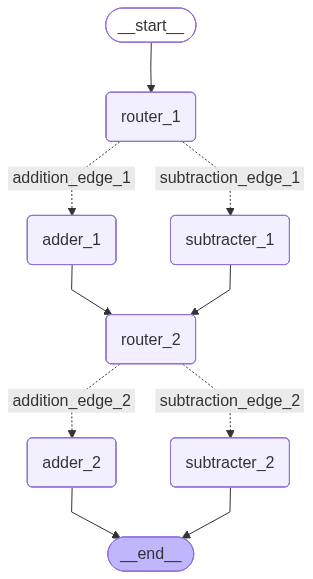

In [20]:
graph = StateGraph(AgentState)

graph.add_node("adder_1", add_node_1)
graph.add_node("subtracter_1", subtract_node_1)
graph.add_node("adder_2", add_node_2)
graph.add_node("subtracter_2", subtract_node_2)
graph.add_node("router_1", lambda state: state)
graph.add_node("router_2", lambda state: state)

graph.add_edge(START, "router_1")
graph.add_conditional_edges(
    "router_1",
    router_node_1,
    {
        "addition_edge_1": "adder_1",
        "subtraction_edge_1": "subtracter_1"
    }
)
graph.add_edge("adder_1", "router_2")
graph.add_edge("subtracter_1", "router_2")
graph.add_conditional_edges(
    "router_2",
    router_node_2, 
    {
        "addition_edge_2": "adder_2",
        "subtraction_edge_2": "subtracter_2"
    }
)
graph.add_edge("adder_2", END)
graph.add_edge("subtracter_2", END)

app = graph.compile()
app

In [21]:
initial_state = AgentState(num1=10, num2=4, operation1="-", num3=3, num4=9, operation2="+")
print(app.invoke(initial_state))

{'num1': 10, 'num2': 4, 'operation1': '-', 'num3': 3, 'num4': 9, 'operation2': '+', 'finalNum1': 6, 'finalNum2': 12}
